In [2]:
#!pip install matplotlib

Shapiro's test for Tiktok:(np.float64(0.9340769133290602), np.float64(0.003967882015134368))
Levene's test:(np.float64(43.281735197858666), np.float64(6.904125799886384e-16))
t-statistic for Tiktok vs Facebook: -1.7412249112477374
P-value: 0.08713568716143558
t-statistic for Tiktok vs Population: -1.2212771406252259
P-value: 0.22709789379298112
Wilcoxon-statistic for Tiktok vs Facebook: 653.0
P-value: 0.1680509414439949
Wilcoxon-statistic for Tiktok vs Population: 705.0
P-value: 0.3343731497453104


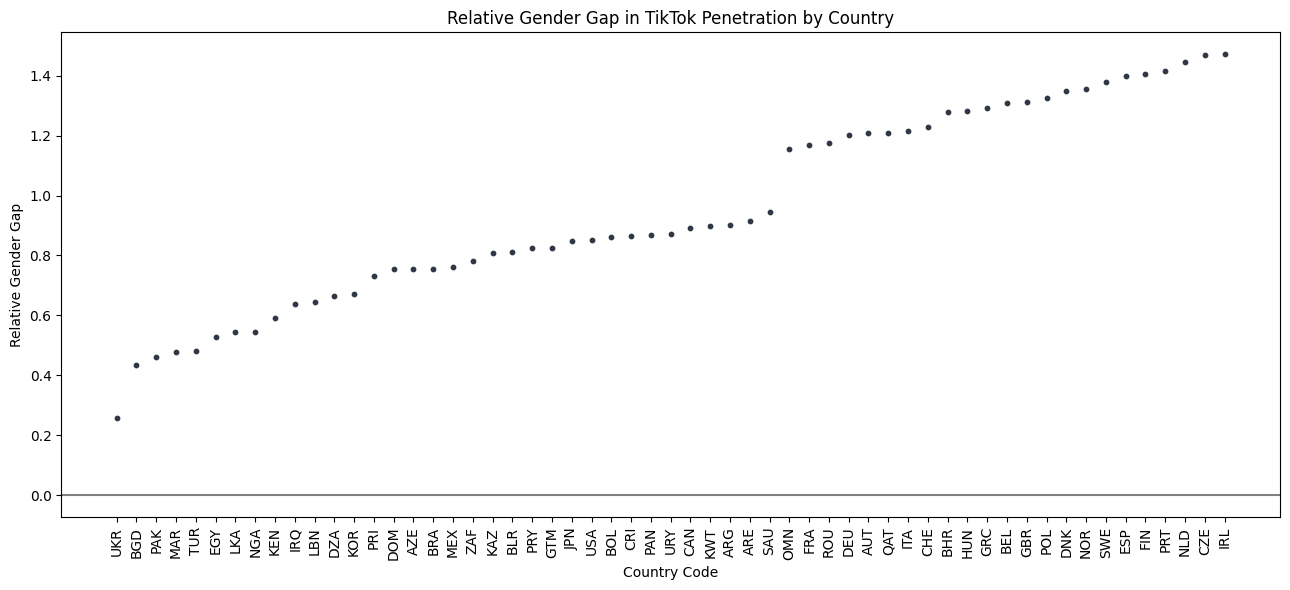

In [76]:
#### Statistical Tests and Analyses
import math
import numpy as np
from scipy.stats import shapiro, ttest_rel, levene, wilcoxon, mannwhitneyu, ranksums
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

TT = Path("../outputs/gap_by_country.csv")
FB = Path("../merged_fb.csv")

tt_df = pd.read_csv(TT, encoding="utf-8-sig")
fb_df = pd.read_csv(FB, encoding="utf-8-sig")

#perform Shapiro-Wilk test for normality, H0=normal distribution, If the p-value of the test > α = .05, then the data is assumed to be normally distributed
tiktok = tt_df["tt_fm"]
stat, p = shapiro(tiktok)
print(f"Shapiro's test for Tiktok:{stat, p}")

#test homogeneity of variance, H0=euqal variance, homoscedastic, if we get a p-value > 0.05 we can assume that our data is heteroscedastic (which is what we want)
facebook = fb_df["fb_fm"]
population = tt_df["pop_fm"]

stat, p = levene(tiktok, facebook, population)

print(f"Levene's test:{stat, p}")

# Perform two-sample paired t-test if assumptions are met

t_statistic_ft, p_value_ft = ttest_rel(tiktok, facebook)
t_statistic_pt, p_value_pt = ttest_rel(tiktok, population)

# Output the results
print(f"t-statistic for Tiktok vs Facebook: {t_statistic_ft}")
print(f"P-value: {p_value_ft}")

print(f"t-statistic for Tiktok vs Population: {t_statistic_pt}")
print(f"P-value: {p_value_pt}")

# Perform Wilcoxon test if assumptions are not met

t_statistic_ft, p_value_ft = wilcoxon(tiktok, facebook)
t_statistic_pt, p_value_pt = wilcoxon(tiktok, population)

# Output the results
print(f"Wilcoxon-statistic for Tiktok vs Facebook: {t_statistic_ft}")
print(f"P-value: {p_value_ft}")

print(f"Wilcoxon-statistic for Tiktok vs Population: {t_statistic_pt}")
print(f"P-value: {p_value_pt}")


### Create Scatterplot of Tiktok Relative Gender Gap
tt_df_sorted = tt_df.sort_values("relative_gap", ascending=True)
plt.figure(figsize=(13, 6))
plt.scatter(tt_df_sorted["country_code"], tt_df_sorted["relative_gap"],color='#303845', s=10)

# Add horizontal line at 0 to show baseline
plt.axhline(0, color='gray')

# Labels and title
plt.xticks(rotation=90)
plt.xlabel("Country Code")
plt.ylabel("Relative Gender Gap")
plt.title("Relative Gender Gap in TikTok Penetration by Country")
plt.tight_layout()
plt.grid(False)
plt.show()

Shapiro: reject H0 -> tiktok data not normally distributed <br>
Levene: reject H0 -> different variances, heteroscedastic <br>
Wilcoxon: both p-values are >.05, fail to reject H0, Tiktok values are not statistically different from the facebook or population values <br>
The results showed no statistically significant difference between TikTok and Facebook gender ratios (Wilcoxon statistic = 681.0, p > 0.05), nor between TikTok and the population gender ratios (Wilcoxon statistic = 735.0, p >0.05).


In [70]:
# compare audience estimates to population
# descriptive table summary:
######## N countries, min, max, mean, sd
#Gender + Overall
# TT Pen
# TT Gap
# Pop Gap
# Rel Gap

tbl = pd.read_csv("../outputs/summary_table.csv")

import pandas as pd

# Load summary table
tbl = pd.read_csv("../outputs/summary_table.csv")

# Mapping original variable names to multi-level rows
mapping = {
    'tiktok_female':    ('Female', 'TikTok aud. estimate'),
    'pen_female':       ('Female', 'TikTok Penetration \%'),
    #'pop_female':       ('Female', 'Population'),
    
    'tiktok_male':      ('Male', 'TikTok  aud. estimate'),
    'pen_male':         ('Male', 'TikTok Penetration \%'),
    #'pop_male':         ('Male', 'Population'),
    
    'tiktok_total':     ('Total', 'TikTok  aud. estimate'),
    'pen_total':        ('Total', 'TikTok Penetration \%'),
    'pop_total':        ('Total', 'Population'),
    'tt_fm':            ('Total', 'TikTok Gender Gap'),
    #'pop_fm':           ('Total', 'Population Gender Gap'),
    'relative_gap':        ('Total', 'Relative Gender Gap'),
}

# Subset and rename for LaTeX-ready table
rows = []
for var, (gender, label) in mapping.items():
    row = tbl[tbl['Variable'] == var].iloc[0].copy()

    n = f"{int(round(row['count'])):,}"
    mean = f"{row['mean']:,.2f}"
    if var.startswith('pen_'):
        row[['mean', 'std', 'min', 'max']] *= 100
    
    rows.append({
        'Gender': gender,
        'Variable': label,
        'N': f"{int(round(row['count'])):,}",
        'Mean': f"{row['mean']:,.2f}",
        'SD': f"{row['std']:,.2f}" if pd.notna(row['std']) else '',
        'Min': f"{row['min']:,.2f}" if pd.notna(row['min']) else '',
        'Max': f"{row['max']:,.2f}" if pd.notna(row['max']) else '',
    })

# Create clean DataFrame
latex_df = pd.DataFrame(rows)

# Replace repeated gender with blank for grouping display
latex_df['Gender'] = latex_df['Gender'].mask(latex_df['Gender'].duplicated(), '')

# Create LaTeX table string
latex_str = latex_df.to_latex(
    index=False,
    column_format='l l r r r r r',
    escape=False,
    header=['Gender', 'Variable', 'N', 'Mean', 'SD', 'Min', 'Max']
)

# Insert booktabs rules for nicer styling
latex_str = latex_str.replace('\\toprule', '\\toprule')\
                     .replace('\\midrule', '\\midrule')\
                     .replace('\\bottomrule', '\\bottomrule')

# Save to .tex file
with open("../outputs/publication_ready_table.tex", "w") as f:
    f.write(latex_str)

# Optional: print
print(latex_str)



\begin{tabular}{l l r r r r r}
\toprule
Gender & Variable & N & Mean & SD & Min & Max \\
\midrule
Female & TikTok aud. estimate & 285 & 2,584,752.63 & 4,294,618.61 & 29,500.00 & 34,977,000.00 \\
 & TikTok Penetration \% & 285 & 117.44 & 112.77 & 4.89 & 631.96 \\
Male & TikTok  aud. estimate & 285 & 3,863,435.09 & 7,343,108.83 & 29,500.00 & 50,305,500.00 \\
 & TikTok Penetration \% & 285 & 151.75 & 334.11 & 9.44 & 5,013.35 \\
Total & TikTok  aud. estimate & 285 & 1,837,733,500.00 & 0.00 & 1,837,733,500.00 & 1,837,733,500.00 \\
 & TikTok Penetration \% & 285 & 116.60 & 0.00 & 116.60 & 116.60 \\
 & Population & 285 & 1,576,106,728.00 & 0.00 & 1,576,106,728.00 & 1,576,106,728.00 \\
 & TikTok Gender Gap & 285 & 0.95 & 0.35 & 0.09 & 1.91 \\
 & Relative Gender Gap & 285 & 1.02 & 0.36 & 0.09 & 2.36 \\
\bottomrule
\end{tabular}



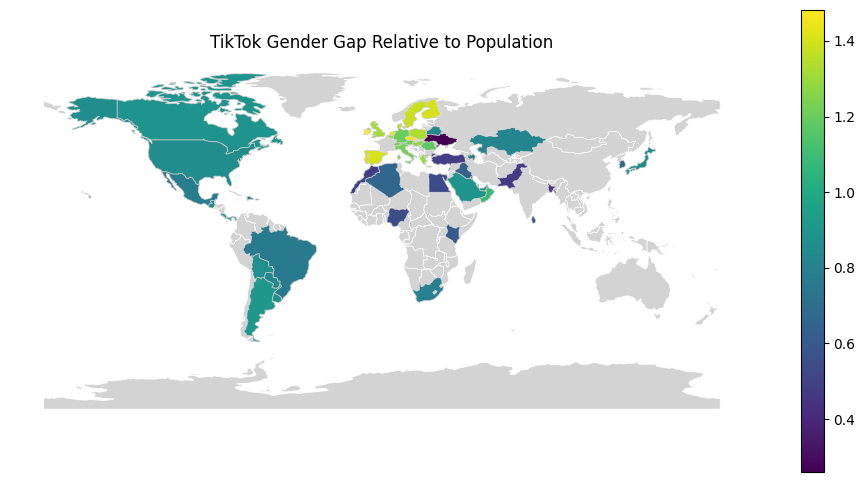

In [53]:
# creating map of tiktok 
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Example data
df = pd.read_csv("../outputs/gap_by_country.csv")
df = df[["country_code","relative_gap"]]

# Load world geometry
world = gpd.read_file("map/ne_110m_admin_0_countries.shp")

# Merge
df = df.rename(columns={"country_code": "ISO_A3"})
merged = world.merge(df, on='ISO_A3', how='left')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

merged.dropna(subset=["relative_gap"]).plot(
    column='relative_gap',
    cmap='viridis',
    linewidth=0.5,
    edgecolor='0.8',
    legend=True,
    ax=ax
)

ax.set_title('TikTok Gender Gap Relative to Population')
plt.axis('off')
plt.show()



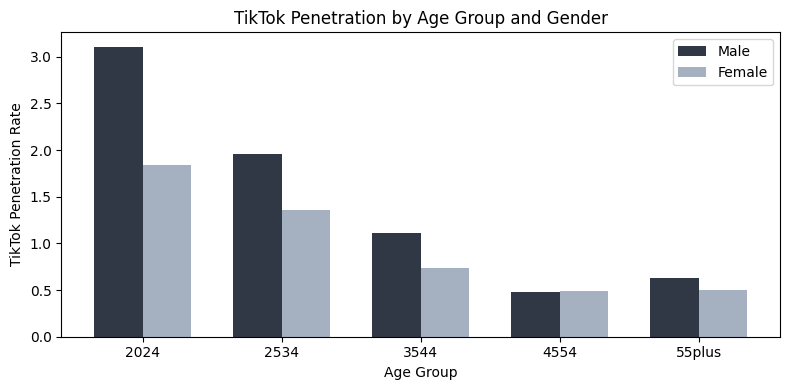

C:\Users\Hanna\AppData\Local\Temp\ipykernel_44172\1559364492.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


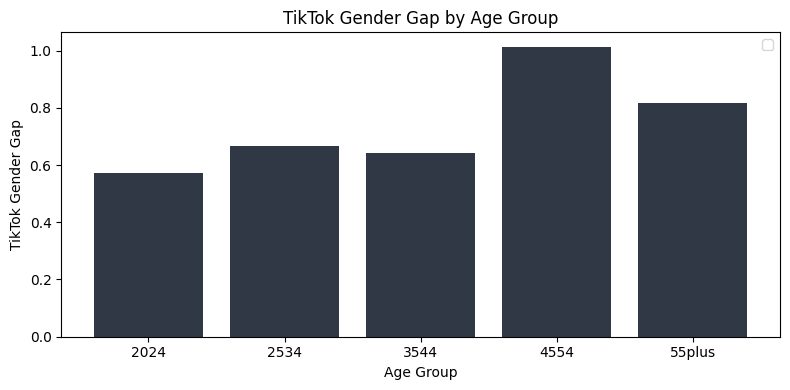

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/penetration_by_bucket.csv")
# Plot histogram of TikTok penetration by age bucket
df['bucket'] = df['bucket'].astype(str)
plt.figure(figsize=(8, 4))
x = np.arange(len(df['bucket']))  # label locations
width = 0.35
plt.bar(x - width/2, df['pen_male'], width, label='Male', color='#303845')
plt.bar(x + width/2, df['pen_female'], width, label='Female', color='#7F91A7', alpha=0.7)

# Labeling
plt.xlabel("Age Group")
plt.ylabel("TikTok Penetration Rate")
plt.title("TikTok Penetration by Age Group and Gender")
plt.xticks(x, df['bucket'])  # Set custom x-axis labels
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df['bucket'], df['tt_fm'], color='#303845')

# Labeling
plt.xlabel("Age Group")
plt.ylabel("TikTok Gender Gap")
plt.title("TikTok Gender Gap by Age Group")
plt.legend()
plt.tight_layout()
plt.show()

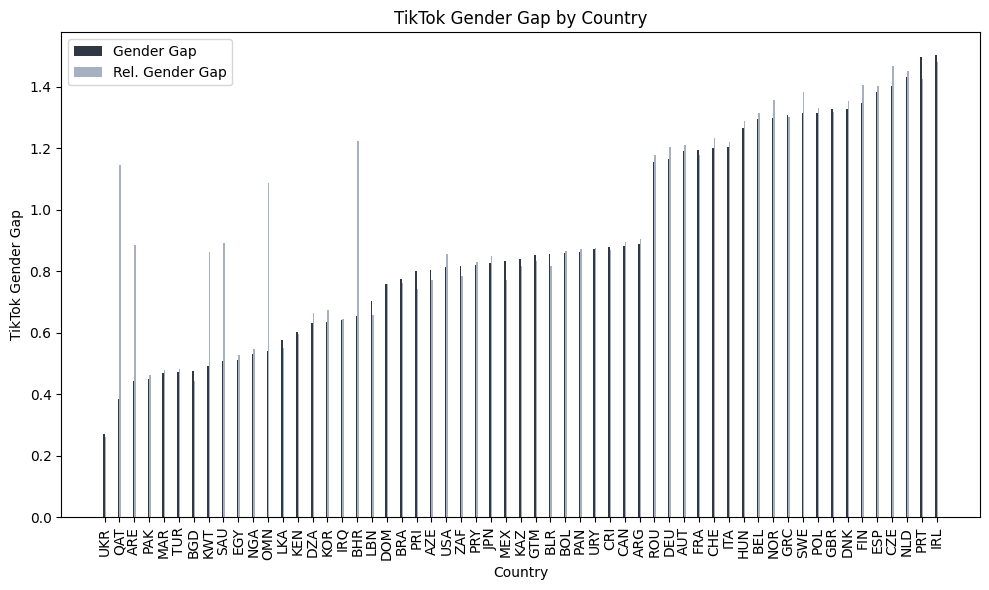

In [33]:

df = pd.read_csv("../outputs/gap_by_country.csv")
# Plot histogram of TikTok penetration by age bucket
plt.figure(figsize=(10, 6))
df = df.sort_values(by='tt_fm') 
x = np.arange(len(df['country_code']))  # label locations
width = 0.1
plt.bar(x - width/2, df['tt_fm'], width, label='Gender Gap', color='#303845')
plt.bar(x + width/2, df['relative_gap'], width, label='Rel. Gender Gap', color='#7F91A7', alpha=0.7)

# Labeling
plt.xlabel("Country")
plt.ylabel("TikTok Gender Gap")
plt.title("TikTok Gender Gap by Country")
plt.xticks(rotation=90)
plt.xticks(x, df['country_code'])
plt.legend()
plt.tight_layout()
plt.show()

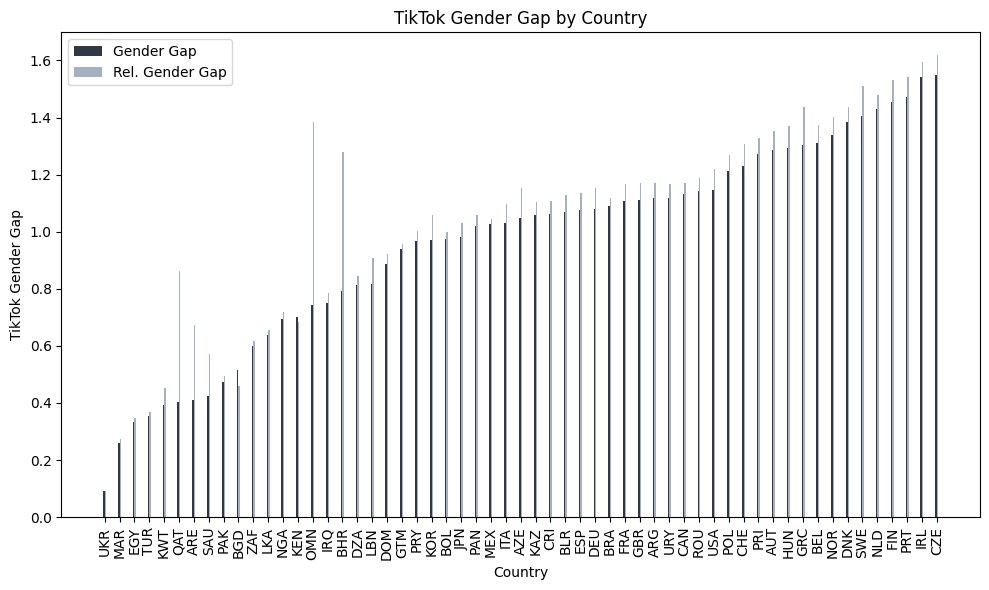

    country_code   delta_pop  delta_pop_pct
265          UKR  52869057.0      26.736071
250          SAU  19686944.0       7.322497
260          TUR  42890008.0       6.963803
165          KWT   1602850.0       6.208987
240          QAT    951504.0       6.003331
180          MAR  17665490.0       5.989297
146          JPN  62942717.0       5.181203
0            ARE   4370420.0       4.757800
251          SAU  30479457.0       4.101087
145          JPN  24284659.0       3.965916
110
Percentage of rows that have higher TikTok estimates than population: 38.60%
Avg amount TikTok estimates higher than population: 6,878,414.65
107
Percentage of rows that have higher TikTok estimates than population w/o Outlier: 37.54%
Avg amount TikTok estimates higher than population w/o Outlier: 6,361,195.43
Total TikTok estimate male: 1,101,079,000.00
Total TikTok estimate female: 736,654,500.00
    country_code bucket  tiktok_male  tiktok_female   pop_male  pop_female  \
260          TUR   2024   362515

In [72]:
df = pd.read_csv("../outputs/penetration_by_country.csv")
df_age = df[df["bucket"]=="2024"]
# Plot histogram of TikTok penetration by age bucket
plt.figure(figsize=(10, 6))
df_age = df_age.sort_values(by='tt_fm') 
x = np.arange(len(df_age['country_code']))  # label locations
width = 0.1
plt.bar(x - width/2, df_age['tt_fm'], width, label='Gender Gap', color='#303845')
plt.bar(x + width/2, df_age['relative_gap'], width, label='Rel. Gender Gap', color='#7F91A7', alpha=0.7)

# Labeling
plt.xlabel("Country")
plt.ylabel("TikTok Gender Gap")
plt.title("TikTok Gender Gap by Country")
plt.xticks(rotation=90)
plt.xticks(x, df_age['country_code'])
plt.legend()
plt.tight_layout()
plt.show()

df["delta_pop"] = df["tiktok_female"]+df["tiktok_male"]-df["pop_female"]-df["pop_male"]
df["delta_pop_pct"] = df["delta_pop"]/(df["pop_female"]+df["pop_male"])
top_10 = df.nlargest(10, "delta_pop_pct")
num_positive = (df["delta_pop"] > 0).sum()
pct_positive = num_positive/len(df)
avg_positive = df[df["delta_pop"] > 0]["delta_pop"].mean()
print(top_10[["country_code","delta_pop", "delta_pop_pct"]])
print(num_positive)
print(f"Percentage of rows that have higher TikTok estimates than population: {pct_positive:.2%}")
print(f"Avg amount TikTok estimates higher than population: {avg_positive:,.2f}")

df_trim=df[df["country_code"]!="UKR"]
num_positive_ = (df_trim["delta_pop"] > 0).sum()
pct_positive_ = num_positive_/len(df)
avg_positive_ = df_trim[df_trim["delta_pop"] > 0]["delta_pop"].mean()
print(num_positive_)
print(f"Percentage of rows that have higher TikTok estimates than population w/o Outlier: {pct_positive_:.2%}")
print(f"Avg amount TikTok estimates higher than population w/o Outlier: {avg_positive_:,.2f}")

total_male = df["tiktok_male"].sum()
total_female = df["tiktok_female"].sum()
print(f"Total TikTok estimate male: {total_male:,.2f}")
print(f"Total TikTok estimate female: {total_female:,.2f}")


print(df_trim[df_trim['pen_male'] == df_trim['pen_male'].max()])

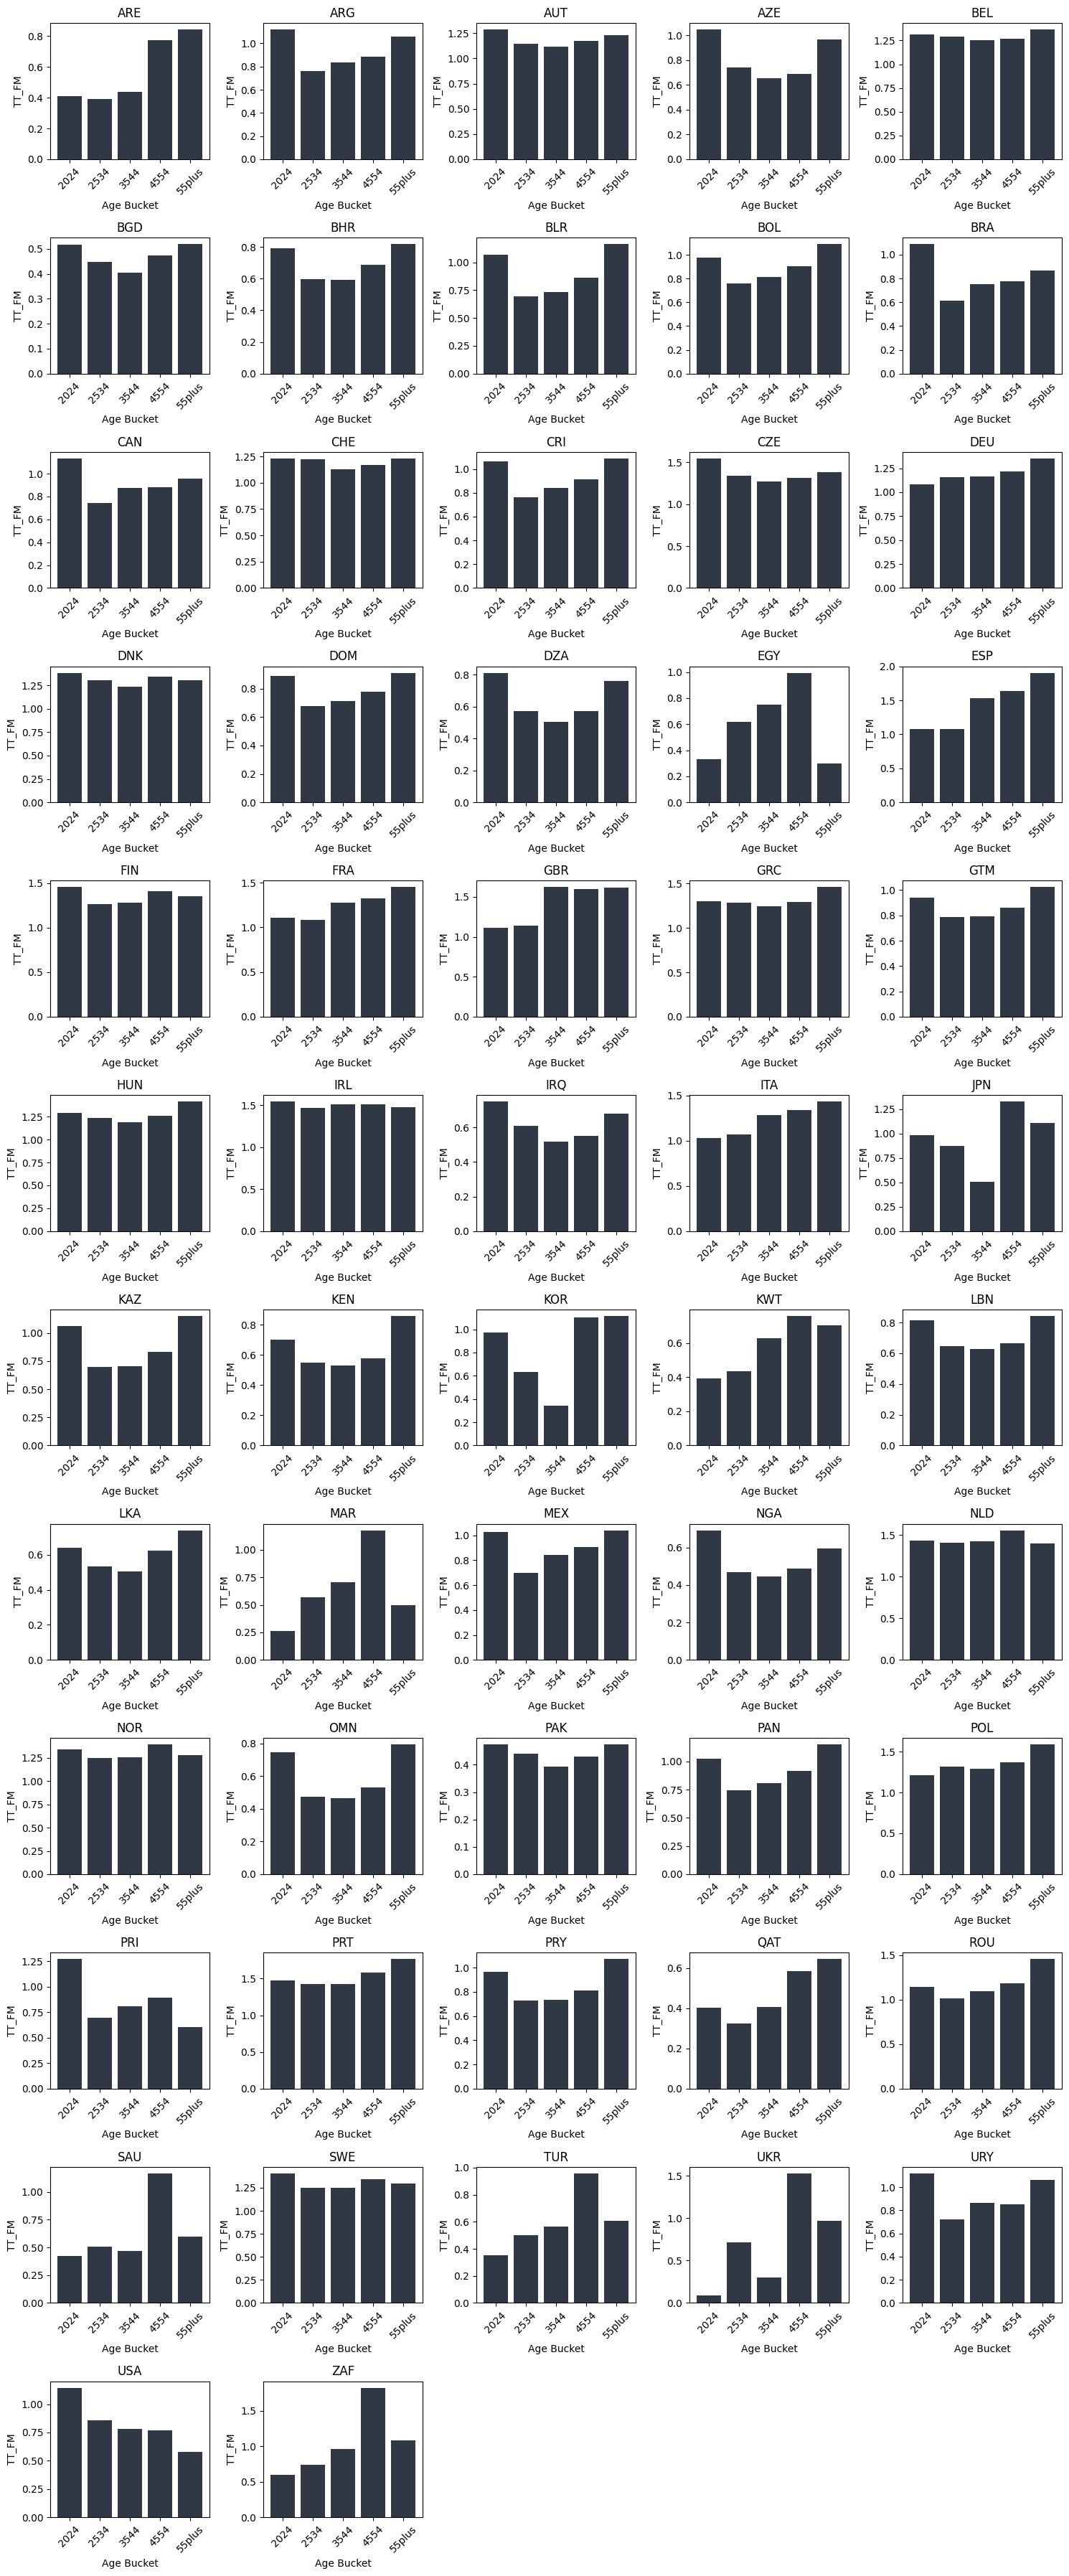

    country_code  bucket  tiktok_male  tiktok_female   pop_male  pop_female  \
105          FRA    2024    2729500.0      3027000.0  2192279.0   2084824.0   
106          FRA    2534    3273500.0      3547500.0  3943909.0   3895621.0   
107          FRA    3544    1897500.0      2414000.0  4026014.0   4204429.0   
108          FRA    4554    1333000.0      1766000.0  4281636.0   4374865.0   
109          FRA  55plus    1090500.0      1580500.0  4174183.0   4481437.0   

     pen_male  pen_female  gap_abs  gap_pct   tt_fm  pop_fm  relative_gap  
105    1.2451      1.4519  -0.2069  -7.6704  1.1090  0.9510        1.1661  
106    0.8300      0.9106  -0.0806  -4.6318  1.0837  0.9878        1.0971  
107    0.4713      0.5742  -0.1028  -9.8374  1.2722  1.0443        1.2182  
108    0.3113      0.4037  -0.0923 -12.9147  1.3248  1.0218        1.2965  
109    0.2612      0.3527  -0.0914 -14.8924  1.4493  1.0736        1.3499  


C:\Users\Hanna\AppData\Local\Temp\ipykernel_44172\2960092051.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


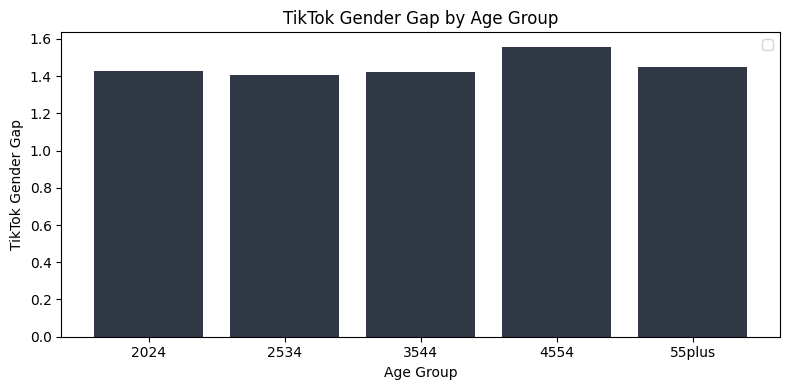

In [ ]:
# bar charts per group fm ratio for PAK, FRA, NLD
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_csv("../outputs/penetration_by_country.csv")
#df = df[df["country_code"].isin(["PAK","FRA","NLD"])]
# Get unique countries
countries = df['country_code'].unique()

# Calculate grid dimensions
n_countries = len(countries)
cols = 5  # or adjust based on your preference
rows = int(np.ceil(n_countries / cols))

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten() if n_countries > 1 else [axes]

# Create bar chart for each country
for i, country in enumerate(countries):
    country_data = df[df['country_code'] == country]
    
    axes[i].bar(country_data['bucket'], country_data['tt_fm'],color='#303845')
    axes[i].set_title(f'{country}')
    axes[i].set_xlabel('Age Bucket')
    axes[i].set_ylabel('TT_FM')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for i in range(n_countries, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# select NLD, relatively equal above 1, QAT below 1, lower gap in older, DE relatively equal, 

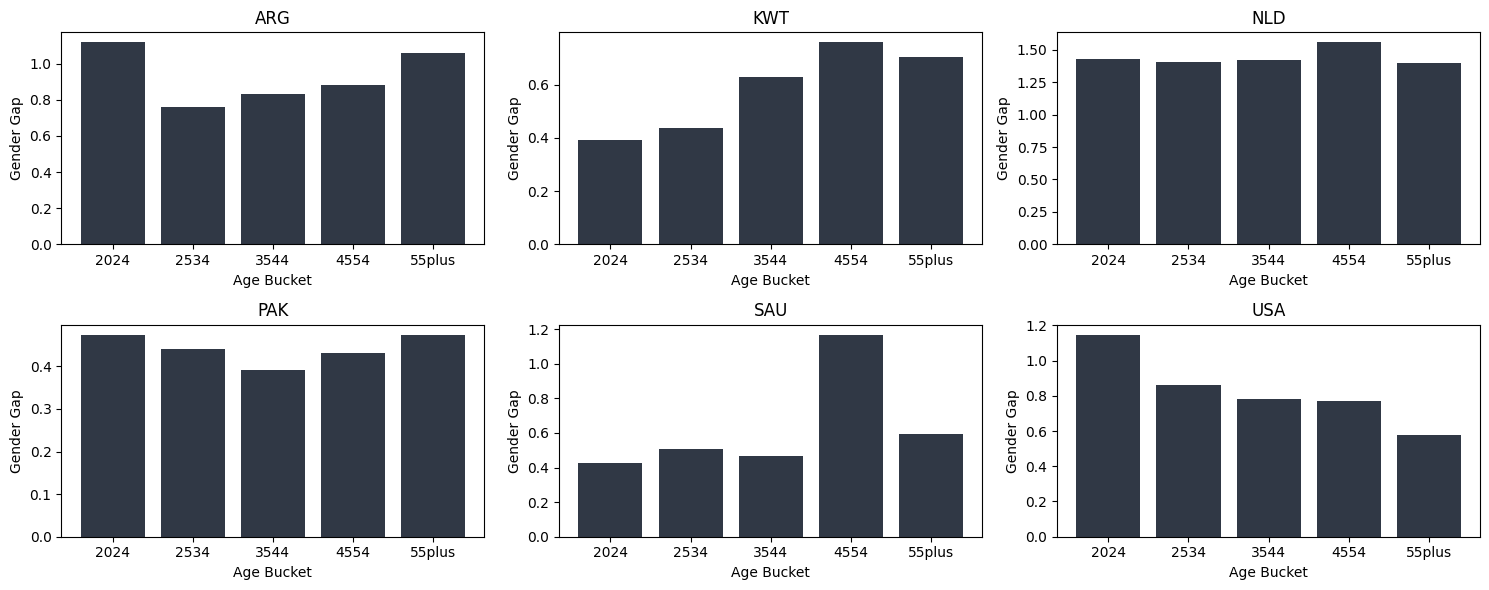

In [89]:
# Load your data
df = pd.read_csv("../outputs/penetration_by_country.csv")
df = df[df["country_code"].isin(["SAU","NLD","USA","ARG","KWT","PAK"])]
# Get unique countries
countries = df['country_code'].unique()

# Calculate grid dimensions
n_countries = len(countries)
cols = 3  # or adjust based on your preference
rows = int(np.ceil(n_countries / cols))

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten() if n_countries > 1 else [axes]

# Create bar chart for each country
for i, country in enumerate(countries):
    country_data = df[df['country_code'] == country]
    
    axes[i].bar(country_data['bucket'], country_data['tt_fm'],color='#303845')
    axes[i].set_title(f'{country}')
    axes[i].set_xlabel('Age Bucket')
    axes[i].set_ylabel('Gender Gap')

# Hide empty subplots
for i in range(n_countries, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# select NLD, relatively equal above 1, QAT below 1, lower gap in older, 
# 1. stable above 1 -> NLD
# 2. increase, stable around 1 -> DEU
# 3. spike in 4554, below 1 -> SAU
# 4. decrease -> USA
# 5. u shape -> ARG
# 6. inverse u, below 1 -> KWT